# K dwarf star oscillators

This notebook is used to investigate the random and systematic noise level in the time and frequency domain of K dwarf stars.

- Author: Nicholas Jannsen
- Last check: 2026-07-21
- PlatoSim version: `3.7.0-191-g42fc64d4`

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [3]:
# Built-in
import os
import sys
import glob

# Dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# PlatoSim libraries
import platosim.plot      as pt
import platosim.utilities as ut
import platosim.pic       as pic
from platosim.lightcurve   import LightCurve
from platosim.matplotlibrc import setup_notebook
setup_notebook()

from IPython.display import display, HTML
display(HTML("<style>.container {width:80% !important; }</style>"))

In [4]:
# Set global paths
hdir = ut.getHomeDir('inputfiles/data_picsim')
wdir = ut.getWorkDir('kdwarf')
idir = wdir / 'input'
fdir = wdir / 'figures'
sdir = wdir / 'simulations'

---
## 1. Stellar catalogue
---

In [20]:
# Load tPIC catalogue
df = pic.load_pic()

In [30]:
dt = df.copy()

# Stars observable
dt = dt[(dt.ncams != 0) & (dt.Pmag < 11) & (dt.NSR < 50)]

# Seperate dwarf (MS) and sub-gaint (post MS) stars
dt = dt[(dt.R < ut.getMainSequenceLimit(dt.Teff)) & (dt.Teff < 5300)]

<IPython.core.display.Javascript object>


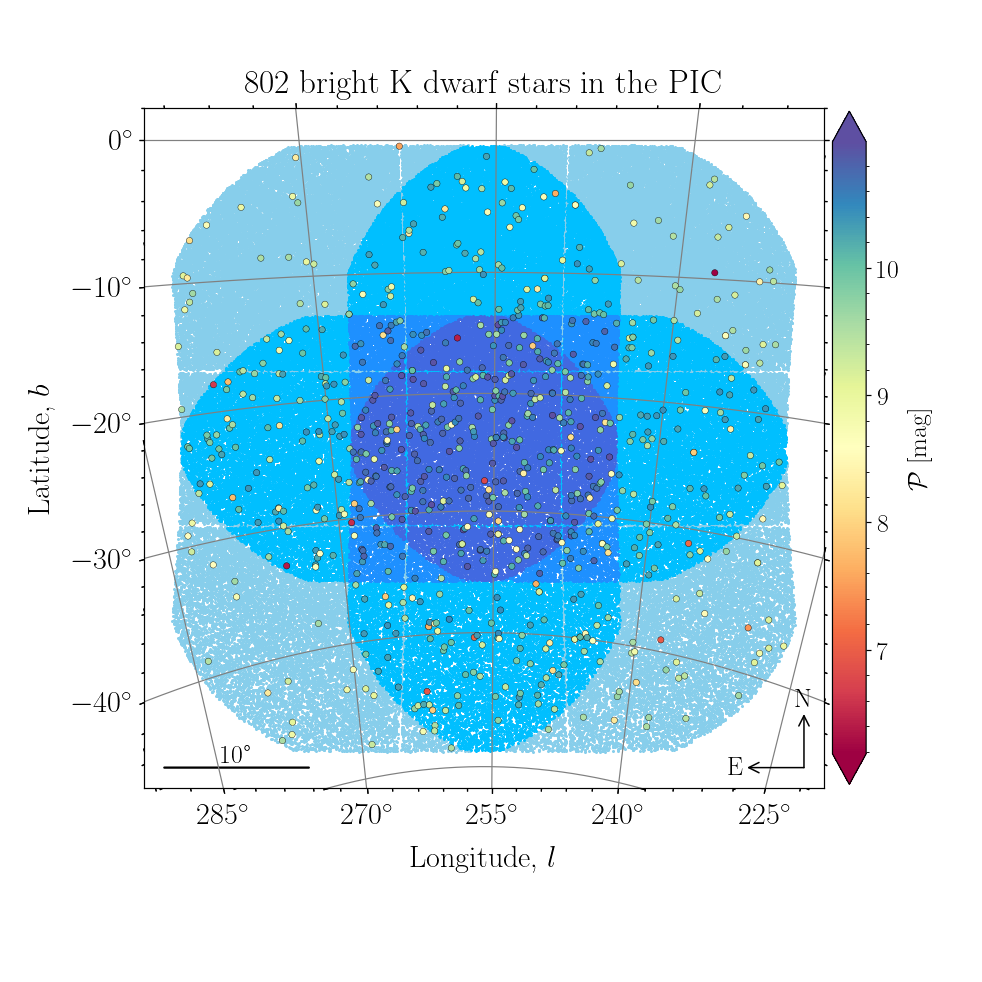

In [31]:
# Plot target in Galactic projection
dx = dt.copy()
fig, ax = pt.plotPlatoFOV(
    'LOPS2', system='galactic', fovSize=29,
    raStars=dx.ra, decStars=dx.dec, c=dx.Pmag, ncamStars=True,
    clabel=r'$\mathcal{P}$ [mag]', s=70, lw=0.25, figsize=(9,9),
    title=f'{dx.shape[0]} bright K dwarf stars in the PIC',
)
# fig.savefig(fdir / f'starcat_sky_targets_{filename}.png', bbox_inches='tight', dpi=200)

<IPython.core.display.Javascript object>


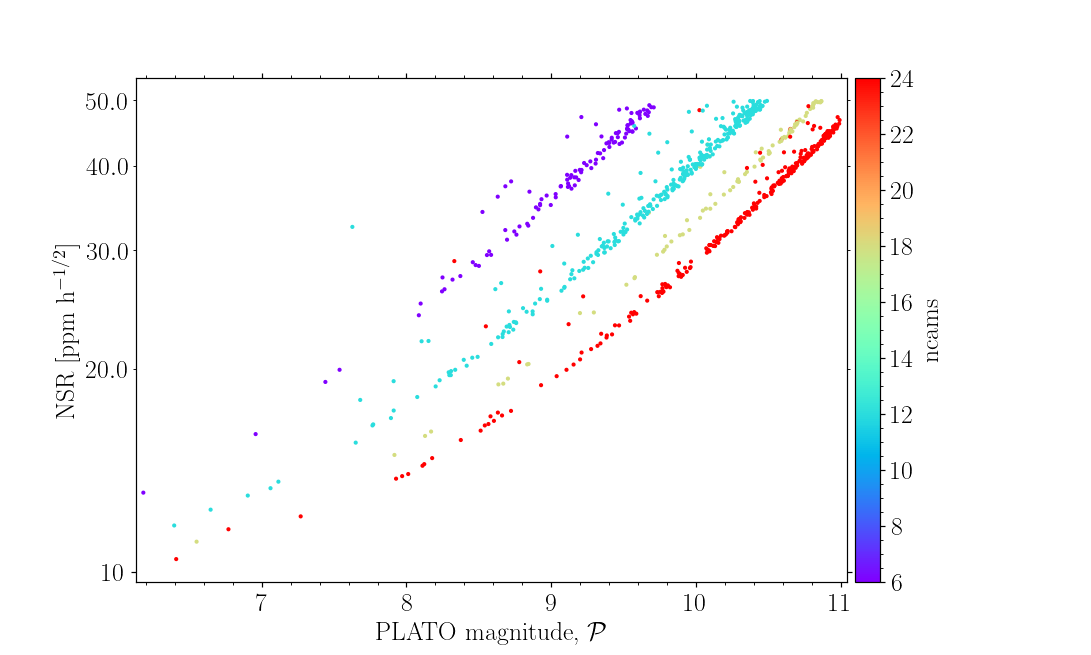

In [32]:
dt['mag'] = dt.Pmag
fig, ax = pt.plotNSRvsMagnitude(dt, column='ncams')

---
## Check LEISA proto-pipeline simulations (by James)
---

In [50]:
path = wdir / 'james'

# Load numpy files
flux_nostel   = np.load(path / '000000605_norm_flux_nostel.npy')
flux_stel     = np.load(path / '000000605_norm_flux_stel.npy')
flux_stel_pdc = np.load(path / '000000605_pdc_corrected_flux_stel.npy')

# Load into a data frame
df_nostel   = pd.DataFrame(flux_nostel.T)
df_stel     = pd.DataFrame(flux_stel.T)
df_stel_pdc = pd.DataFrame(flux_stel_pdc.T)

# Add column names after camera ID
names = [f'ncam{i}' for i in range(1,25)]
df_nostel   = df_nostel.set_axis(names, axis=1)
df_stel     = df_stel.set_axis(names, axis=1)
df_stel_pdc = df_stel_pdc.set_axis(names, axis=1)

In [35]:
time = np.arange(0, df_nostel.shape[0]) * 25

### Camera level

In [36]:
df1 = pd.DataFrame({'time':time, 'flux':df_stel['ncam1']+1})
dc1 = pd.DataFrame({'time':time, 'flux':df_stel_pdc['ncam1']+1})

<IPython.core.display.Javascript object>


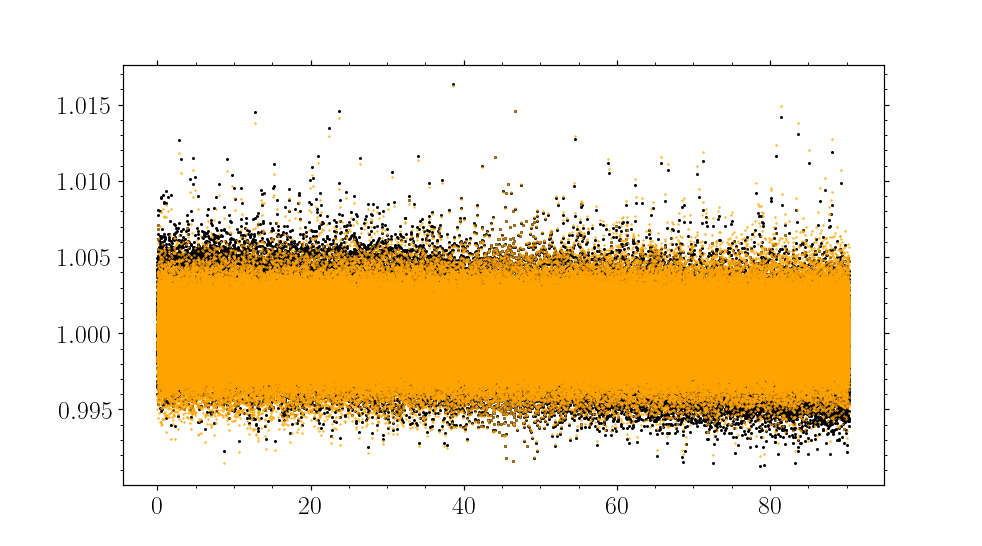

In [37]:
plt.figure(figsize=(9,5))
plt.plot(time/86400, df1.flux, 'k.', ms=2)
plt.plot(time/86400, dc1.flux, '.', c='orange', ms=1);

In [48]:
dt = 25e-6 # [Ms]
sigma = NSR_25s  # [ppm]
PSD_mean = dt*sigma**2 
ASD_mean = np.sqrt(np.pi/2*dt*sigma**2/2)
PSD_mean, ASD_mean

(89.94810958460191, 8.405062764121322)

<IPython.core.display.Javascript object>


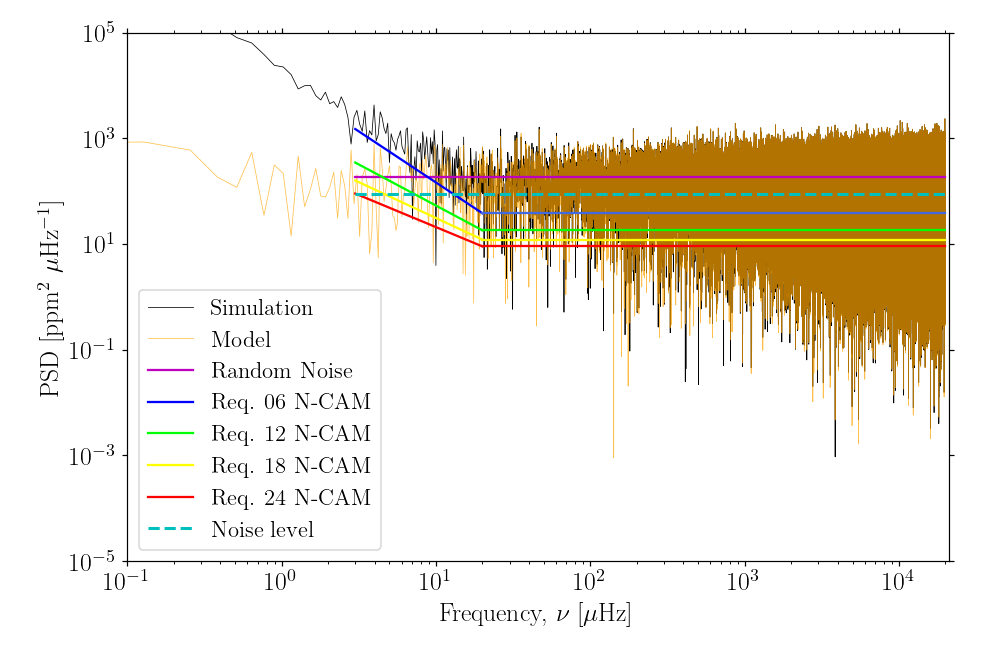

In [49]:
# Check PSD
fig, ax = pt.plotPeriodogram(df1, dc1, noise_level=PSD_mean)
ax.set_xlim(1e-1, 2.1e4)
ax.set_ylim(1e-5, 1e5);

### Mission level

<IPython.core.display.Javascript object>


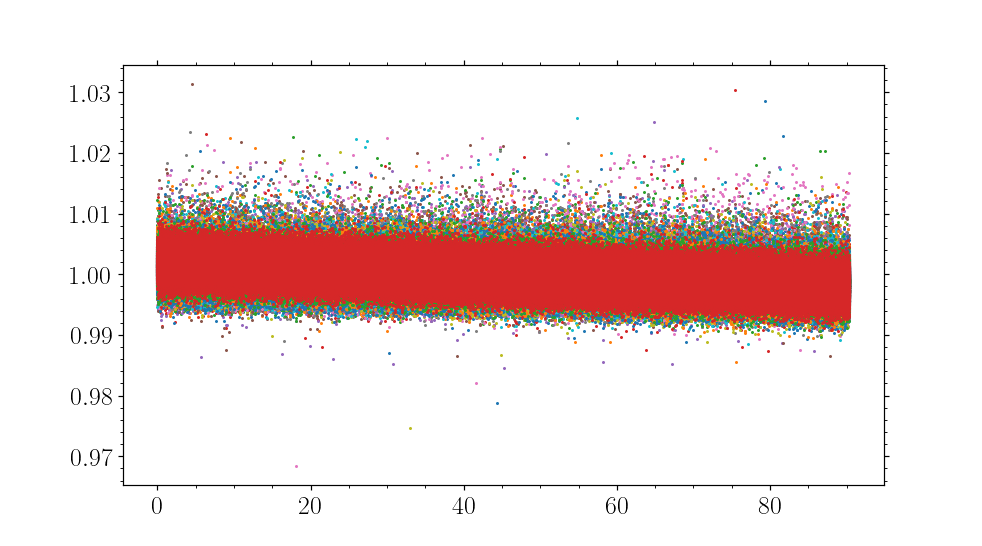

In [51]:
plt.figure(figsize=(9,5))
for n in range(1,25):
    dx = pd.DataFrame({'time':time, 'flux':df_stel[f'ncam{n}']+1})
    plt.plot(time/86400, dx.flux, '.', ms=2)

<IPython.core.display.Javascript object>


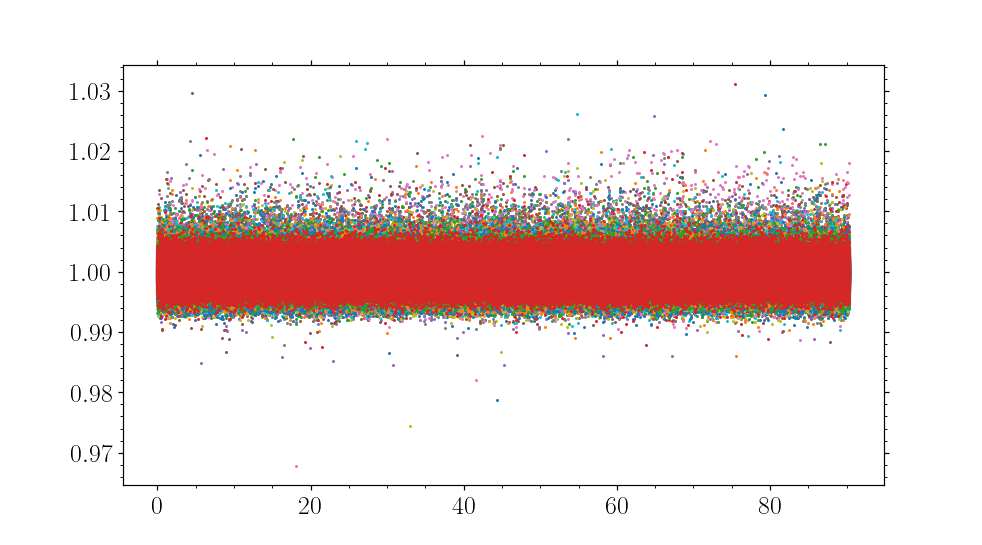

In [52]:
plt.figure(figsize=(9,5))
for n in range(1,25):
    dx = pd.DataFrame({'time':time, 'flux':df_stel_pdc[f'ncam{n}']+1})
    plt.plot(time/86400, dx.flux, '.', ms=2);

In [55]:
# Add all cameras into two columns
df = pd.DataFrame({'time':time, 'flux':df_stel[f'ncam1']+1})
for n in range(2,25):
    dx = pd.DataFrame({'time':time, 'flux':df_stel[f'ncam{n}']+1})
    df = pd.concat([df, dx])

# Sort and average by timings
df = df.sort_values(by="time")
df = df.groupby('time').mean().reset_index()
df

,time,flux
0,0,1.000038
1,25,1.001741
2,50,1.002779
3,75,1.002097
4,100,1.001597
...,...,...
312106,7802650,0.998461
312107,7802675,0.998594
312108,7802700,0.998127
312109,7802725,0.997914


In [67]:
1800 / np.sqrt(24)

367.42346141747674

In [56]:
# Compute NSR camera level
lc = LightCurve(df, mode='reduced')
NSR_25s = lc.get_nsr(binhour=0)
NSR_25s

878.3883358140224

In [59]:
dt = 25e-6 # [Ms]
sigma = df.flux.std()*1e6  # [ppm]
PSD_mean = dt*sigma**2 
ASD_mean = np.sqrt(np.pi/2 * dt * sigma**2/2)
PSD_mean, ASD_mean

(19.290094157774888, 3.892352055413313)

<IPython.core.display.Javascript object>


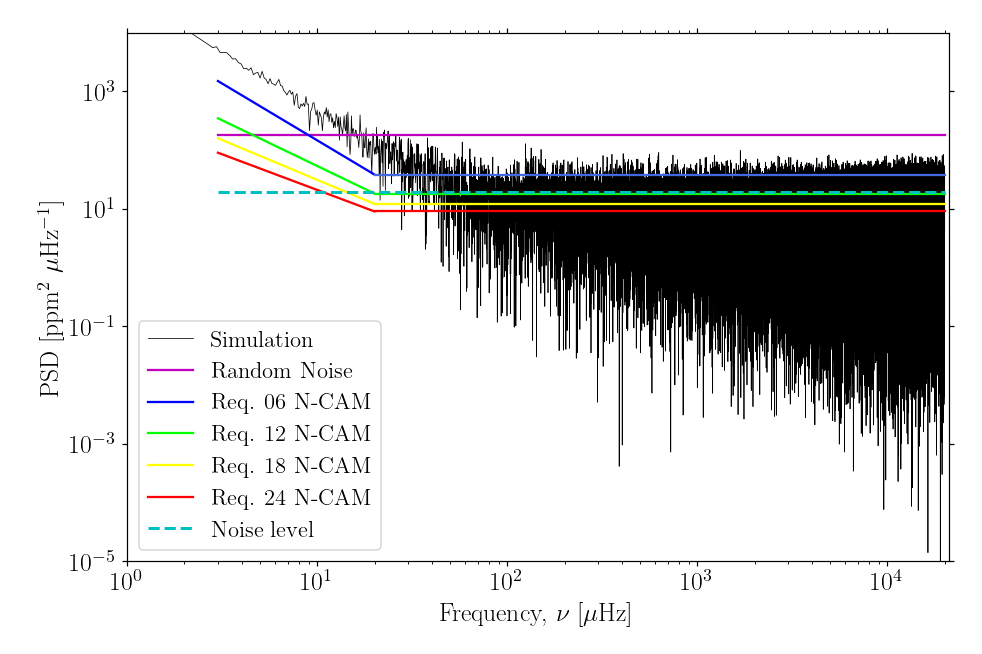

In [60]:
# Check PSD
fig, ax = pt.plotPeriodogram(df, noise_level=PSD_mean)
ax.set_xlim(1e0, 2.1e4)
ax.set_ylim(1e-5, 1e4);

In [65]:
data = pt.compute_double_sided_PSD(df.flux.to_numpy())

<IPython.core.display.Javascript object>


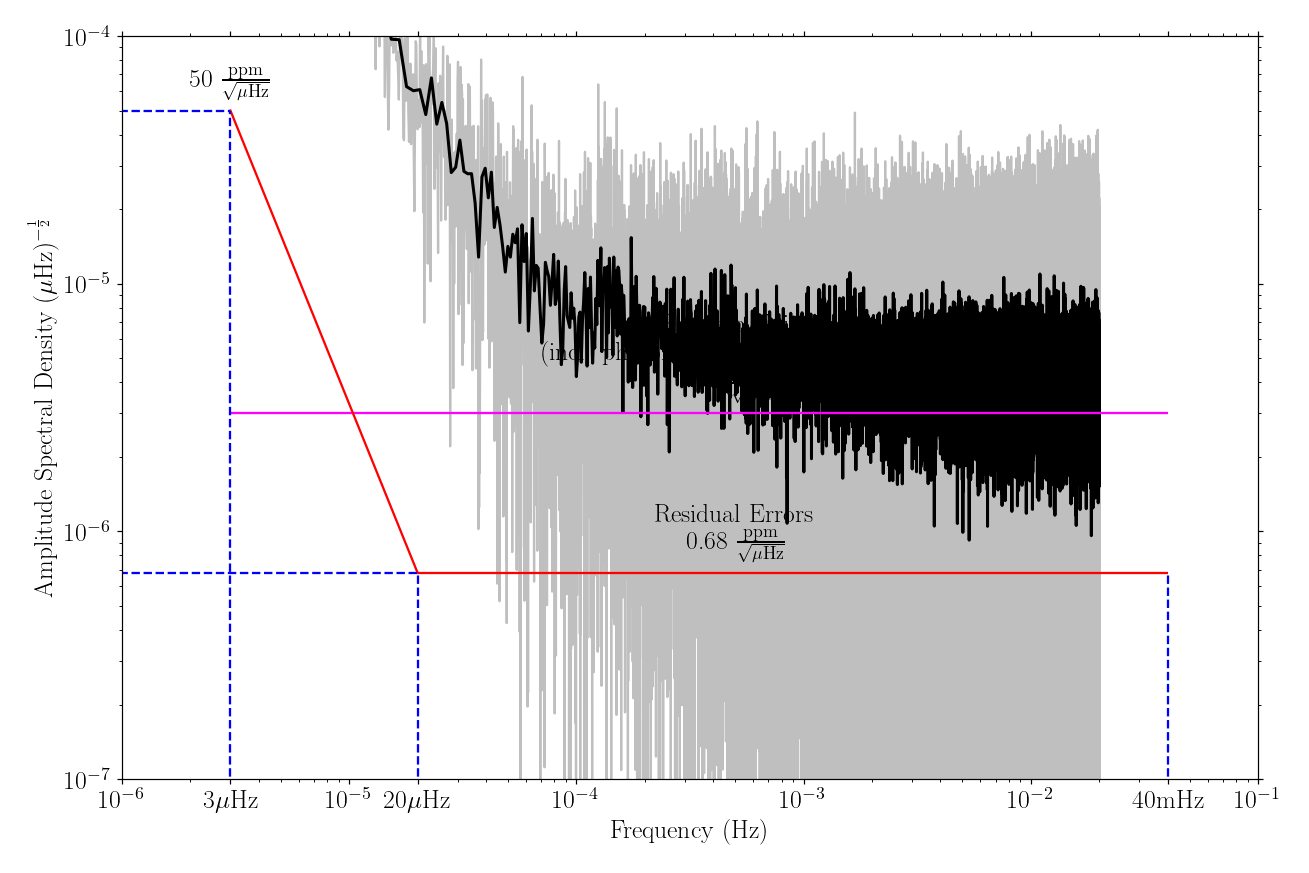

In [66]:
pt.create_performance_figure(data)